# Notebook 02: Dual Model Training

**Purpose**: Train two Random Forest models:
- **Model A**: `RandomForestClassifier` — predicts Replacement Priority (Critical/High/Medium/Low)
- **Model B**: `RandomForestRegressor` — predicts Asset Health Score (0-100 continuous)

**Outputs**:
- `replacement_model.pkl` — trained classifier
- `health_score_model.pkl` — trained regressor
- `label_encoder.pkl` — label encoder for target classes
- Evaluation metrics and visualizations

In [1]:
# === IMPORTS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.preprocessing import LabelEncoder

In [2]:
# === CONFIGURATION ===
BASE_DIR = Path.cwd().parent
MODEL_DIR = BASE_DIR / 'models'
OUTPUT_DIR = BASE_DIR / 'outputs'

print(f'Model directory: {MODEL_DIR}')
print(f'Output directory: {OUTPUT_DIR}')

Model directory: C:\Users\User\Desktop\CaseStudy_AMSOS\ICT_AMSOS\models
Output directory: C:\Users\User\Desktop\CaseStudy_AMSOS\ICT_AMSOS\outputs


---
## Step 1: Load Preprocessed Data

In [3]:
def load_preprocessed():
    try:
        data = joblib.load(MODEL_DIR / 'preprocessed_data.pkl')
        print(f'Features shape: {data["features"].shape}')
        print(f'Classifier target: {len(data["target_classifier"])} samples')
        print(f'Regressor target: {len(data["target_regressor"])} samples')
        print(f'Feature columns: {len(data["feature_columns"])}')
        return data
    except Exception as e:
        print(f'Error loading preprocessed data: {e}')
        print('Run Notebook 01 first.')
        raise

data = load_preprocessed()
X = data['features']
y_class = data['target_classifier']
y_reg = data['target_regressor']
feature_cols = data['feature_columns']

Features shape: (1100, 268)
Classifier target: 1100 samples
Regressor target: 1100 samples
Feature columns: 268


In [4]:
# Encode target labels for classifier
label_encoder = LabelEncoder()
y_class_encoded = label_encoder.fit_transform(y_class)
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print('Class mapping:', class_mapping)

Class mapping: {'Critical': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3)}


---
## Step 2: Train/Test Split (80/20)

In [5]:
# Split for classifier (stratified to maintain class balance)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class_encoded, test_size=0.2, random_state=42
)

# Split for regressor
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f'Classifier - Train: {X_train_c.shape[0]}, Test: {X_test_c.shape[0]}')
print(f'Regressor  - Train: {X_train_r.shape[0]}, Test: {X_test_r.shape[0]}')

Classifier - Train: 880, Test: 220
Regressor  - Train: 880, Test: 220


---
## Step 3: Model A — RandomForestClassifier

In [6]:
print('Training RandomForestClassifier...')
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train_c, y_train_c)
print('Classifier training complete')

Training RandomForestClassifier...


Classifier training complete


### 3.1 Classifier Evaluation

In [7]:
y_pred_c = clf.predict(X_test_c)
y_prob_c = clf.predict_proba(X_test_c)

accuracy = accuracy_score(y_test_c, y_pred_c)
precision = precision_score(y_test_c, y_pred_c, average='weighted')
recall = recall_score(y_test_c, y_pred_c, average='weighted')
f1 = f1_score(y_test_c, y_pred_c, average='weighted')

print('=' * 60)
print('CLASSIFIER PERFORMANCE')
print('=' * 60)
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

CLASSIFIER PERFORMANCE
Accuracy:  0.9773
Precision: 0.9775
Recall:    0.9773
F1 Score:  0.9768


In [8]:
print('\nClassification Report:')
print(classification_report(y_test_c, y_pred_c, target_names=label_encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

    Critical       0.99      1.00      1.00       101
        High       1.00      0.96      0.98        28
         Low       0.95      1.00      0.98        60
      Medium       0.96      0.87      0.92        31

    accuracy                           0.98       220
   macro avg       0.98      0.96      0.97       220
weighted avg       0.98      0.98      0.98       220



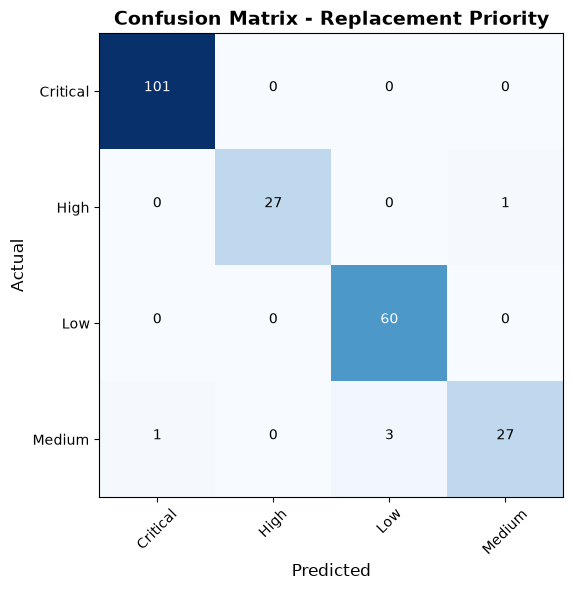

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion Matrix - Replacement Priority', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)

classes = label_encoder.classes_
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes, rotation=45)
ax.set_yticklabels(classes)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

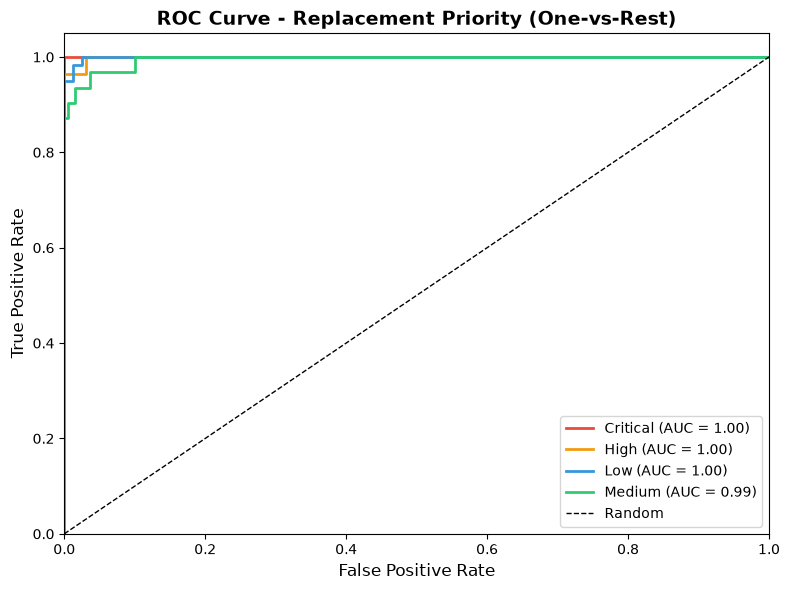

In [10]:
# ROC Curve (One-vs-Rest)
n_classes = len(label_encoder.classes_)
y_test_bin = pd.get_dummies(y_test_c).values

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_c[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
            label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Replacement Priority (One-vs-Rest)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curve.png', dpi=150)
plt.show()

---
## Step 4: Model B — RandomForestRegressor

In [11]:
print('Training RandomForestRegressor...')
reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
reg.fit(X_train_r, y_train_r)
print('Regressor training complete')

Training RandomForestRegressor...


Regressor training complete


### 4.1 Regressor Evaluation

In [12]:
y_pred_r = reg.predict(X_test_r)

r2 = r2_score(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print('=' * 60)
print('REGRESSOR PERFORMANCE')
print('=' * 60)
print(f'R² Score:  {r2:.4f}')
print(f'MAE:       {mae:.4f}')
print(f'RMSE:      {rmse:.4f}')

REGRESSOR PERFORMANCE
R² Score:  0.9518
MAE:       1.1106
RMSE:      2.7577


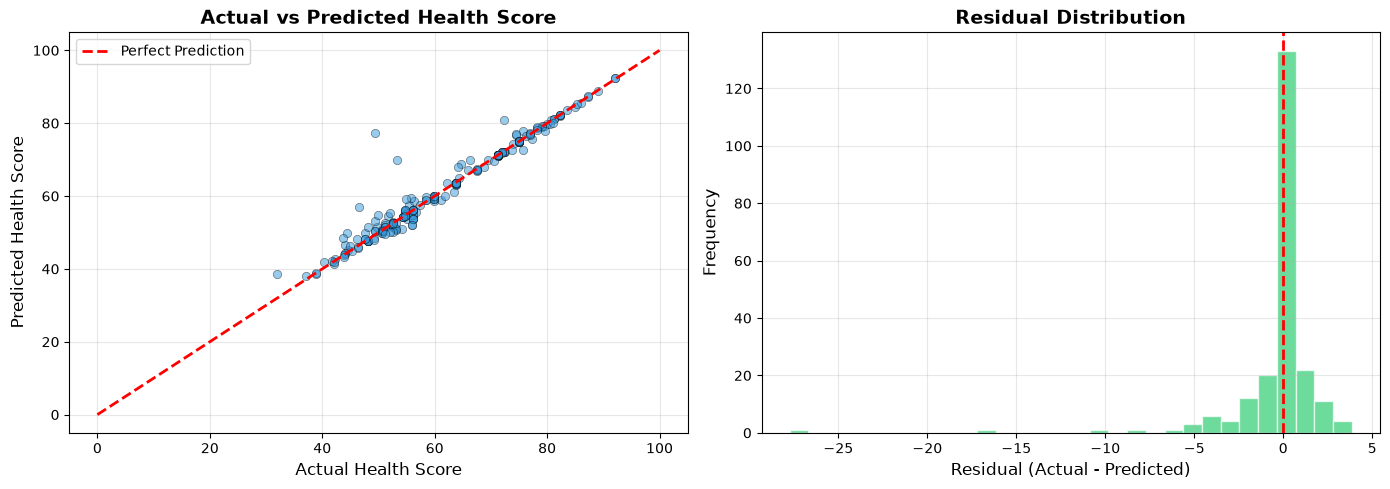

In [13]:
# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test_r, y_pred_r, alpha=0.5, c='#3498db', edgecolors='k', linewidth=0.5)
axes[0].plot([0, 100], [0, 100], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Health Score', fontsize=12)
axes[0].set_ylabel('Predicted Health Score', fontsize=12)
axes[0].set_title('Actual vs Predicted Health Score', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test_r - y_pred_r
axes[1].hist(residuals, bins=30, color='#2ecc71', edgecolor='white', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Residual Distribution', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'regressor_performance.png', dpi=150)
plt.show()

---
## Step 5: Feature Importance (Both Models)

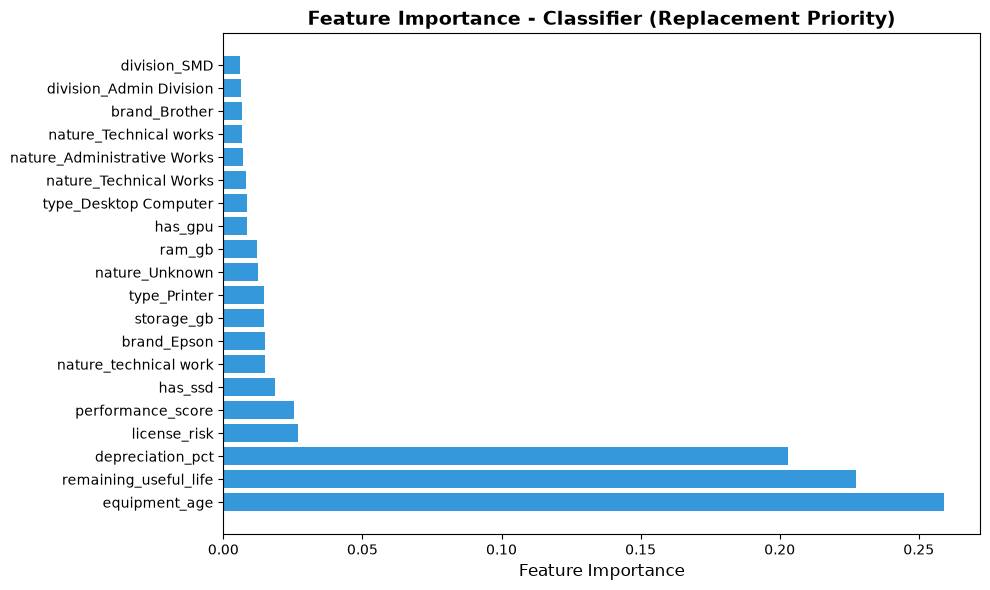

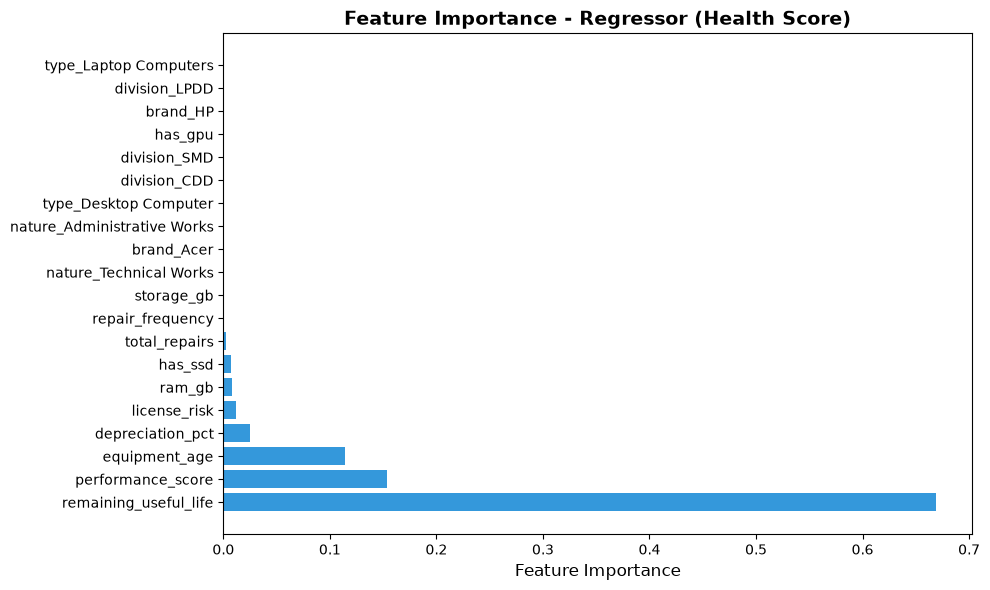

In [14]:
def plot_feature_importance(model, title, filename, top_n=20):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(indices)), importances[indices][::-1], align='center', color='#3498db')
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels([feature_cols[i] for i in indices][::-1])
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()

plot_feature_importance(clf, 'Feature Importance - Classifier (Replacement Priority)', 'feature_importance_clf.png')
plot_feature_importance(reg, 'Feature Importance - Regressor (Health Score)', 'feature_importance_reg.png')

---
## Step 6: Save Models

In [15]:
def save_models(clf, reg, encoder, feature_cols):
    try:
        joblib.dump(clf, MODEL_DIR / 'replacement_model.pkl')
        joblib.dump(reg, MODEL_DIR / 'health_score_model.pkl')
        joblib.dump(encoder, MODEL_DIR / 'label_encoder.pkl')
        joblib.dump(feature_cols, MODEL_DIR / 'feature_columns.pkl')
        print('All models saved successfully!')
        print(f'  {MODEL_DIR / "replacement_model.pkl"}')
        print(f'  {MODEL_DIR / "health_score_model.pkl"}')
        print(f'  {MODEL_DIR / "label_encoder.pkl"}')
        print(f'  {MODEL_DIR / "feature_columns.pkl"}')
    except Exception as e:
        print(f'Error saving models: {e}')
        raise

save_models(clf, reg, label_encoder, feature_cols)

All models saved successfully!
  C:\Users\User\Desktop\CaseStudy_AMSOS\ICT_AMSOS\models\replacement_model.pkl
  C:\Users\User\Desktop\CaseStudy_AMSOS\ICT_AMSOS\models\health_score_model.pkl
  C:\Users\User\Desktop\CaseStudy_AMSOS\ICT_AMSOS\models\label_encoder.pkl
  C:\Users\User\Desktop\CaseStudy_AMSOS\ICT_AMSOS\models\feature_columns.pkl


In [16]:
# Also save a summary of results
results_summary = {
    'classifier': {
        'accuracy': round(accuracy, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4),
        'classes': class_mapping
    },
    'regressor': {
        'r2_score': round(r2, 4),
        'mae': round(mae, 4),
        'rmse': round(rmse, 4)
    },
    'feature_count': len(feature_cols),
    'training_samples': len(X)
}

joblib.dump(results_summary, MODEL_DIR / 'training_summary.pkl')
print('Training summary saved')

Training summary saved


In [17]:
print('\n' + '=' * 60)
print('TRAINING COMPLETE')
print('=' * 60)
print(f'Classifier (Replacement Priority):')
print(f'  Accuracy:  {accuracy:.4f}')
print(f'  F1 Score:  {f1:.4f}')
print(f'  Classes:   {list(class_mapping.keys())}')
print(f'\nRegressor (Health Score):')
print(f'  R²:        {r2:.4f}')
print(f'  MAE:       {mae:.4f}')
print(f'  RMSE:      {rmse:.4f}')
print(f'\nModels saved to: {MODEL_DIR}')


TRAINING COMPLETE
Classifier (Replacement Priority):
  Accuracy:  0.9773
  F1 Score:  0.9768
  Classes:   ['Critical', 'High', 'Low', 'Medium']

Regressor (Health Score):
  R²:        0.9518
  MAE:       1.1106
  RMSE:      2.7577

Models saved to: C:\Users\User\Desktop\CaseStudy_AMSOS\ICT_AMSOS\models


---
## Summary

Notebook 02 completed:
- ✅ Loaded preprocessed data (features + dual targets)
- ✅ Trained RandomForestClassifier for Replacement Priority
- ✅ Trained RandomForestRegressor for Asset Health Score
- ✅ Evaluated both models (metrics + visualizations)
- ✅ Feature Importance analysis for both models
- ✅ Saved all models to `models/` directory
- ✅ Ready for Notebook 03 (Inference)